In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If you haven't loaded your data yet in this session, do it now:
# df = pd.read_csv('your_file_name.csv')

df = pd.read_csv("netflix_titles .csv")
print("Dataset loaded successfully!")
df.info() # This will show you the columns like 'type', 'title', and 'country'

Dataset loaded successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [2]:
# See the total count of missing values for every column
print(df.isnull().sum())

# See the percentage of missing values for each column
print((df.isnull().sum() / len(df)) * 100)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [3]:
# Replace nulls in specific columns with 'Unavailable'
columns_to_fix = ['director', 'cast', 'country']

for col in columns_to_fix:
    df[col] = df[col].fillna('Unavailable')

# Verify the changes
print(df[['director', 'cast', 'country']].isnull().sum())

director    0
cast        0
country     0
dtype: int64


In [4]:
# Drop rows where date_added, rating, or duration are missing
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Final check to ensure 0 nulls remain in the entire dataset
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


In [6]:
# Check null counts for the specific columns you updated
print(df[['director', 'cast', 'country']].isnull().sum())

# Check the entire dataframe to see if any nulls remain
print("\nTotal nulls in dataset:")
print(df.isnull().sum())

director    0
cast        0
country     0
dtype: int64

Total nulls in dataset:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [7]:
# Display the first 5 rows where the director is now 'Unavailable'
df[df['director'] == 'Unavailable'][['title', 'director', 'cast', 'country']].head()

,title,director,cast,country
1,Blood & Water,Unavailable,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa
3,Jailbirds New Orleans,Unavailable,Unavailable,Unavailable
4,Kota Factory,Unavailable,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India
10,"Vendetta: Truth, Lies and The Mafia",Unavailable,Unavailable,Unavailable
14,Crime Stories: India Detectives,Unavailable,Unavailable,Unavailable


In [8]:
# Check the new shape of your data
print(f"Original number of rows: 8807") # The standard Netflix Kaggle dataset size
print(f"Current number of rows: {df.shape[0]}")
print(f"Rows removed: {8807 - df.shape[0]}")

Original number of rows: 8807
Current number of rows: 8790
Rows removed: 17


In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unavailable,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unavailable,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unavailable,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unavailable,Unavailable,Unavailable,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unavailable,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
# Strip whitespace from categorical columns
df['listed_in'] = df['listed_in'].str.strip()
df['rating'] = df['rating'].str.strip()
df['country'] = df['country'].str.strip()

In [11]:
# Create a copy for genre analysis
genre_df = df.copy()

# Split the 'listed_in' string into a list, then 'explode' it into separate rows
genre_df['genre'] = genre_df['listed_in'].str.split(', ')
genre_df = genre_df.explode('genre')

# Now you can see the TRUE top genres
print(genre_df['genre'].value_counts().head(10))

genre
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [12]:
# Define standard Netflix ratings
valid_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'G', 'NR', 'UR']

# Filter or label non-standard ratings
df['rating'] = df['rating'].apply(lambda x: x if x in valid_ratings else 'Other')

In [13]:
# 1. Split the 'duration' column into two parts
# Example: '90 min' becomes ['90', 'min']
temp_duration = df['duration'].str.split(' ', expand=True)

# 2. Assign these to new columns
df['duration_value'] = temp_duration[0]
df['duration_unit'] = temp_duration[1]

# 3. Convert the value column to a numeric type (integer)
df['duration_value'] = pd.to_numeric(df['duration_value'])

# Check the results
df[['title', 'duration', 'duration_value', 'duration_unit']].head()

,title,duration,duration_value,duration_unit
0,Dick Johnson Is Dead,90 min,90,min
1,Blood & Water,2 Seasons,2,Seasons
2,Ganglands,1 Season,1,Season
3,Jailbirds New Orleans,1 Season,1,Season
4,Kota Factory,2 Seasons,2,Seasons


In [14]:
# Standardize 'Seasons' to 'Season' for easier grouping later
df['duration_unit'] = df['duration_unit'].str.replace('Seasons', 'Season')

# Verify unique units
print(df['duration_unit'].unique())

['min' 'Season']


In [15]:

# Save the updated dataframe with the new 'year_added' column
df.to_csv('netflix_m2_task1.csv', index=False)

print("Data successfully saved to 'netflix_m2_task1.csv'!")


Data successfully saved to 'netflix_m2_task1.csv'!


Netflix Content Growth Over Time (Exact Numbers):
--------------------------------------------------
type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          251      175
2017          836      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505
--------------------------------------------------


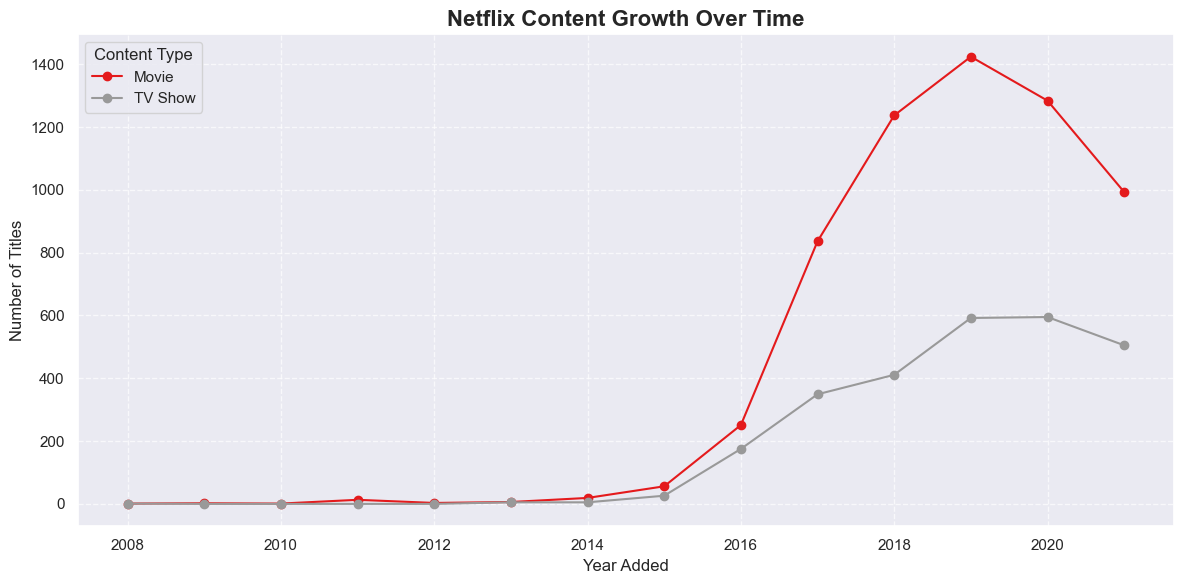

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style
sns.set_theme(style="darkgrid")

# 1. Load the cleaned dataset from Milestone 1
# (Ensure 'netflix_cleaned.csv' is in your working directory)
df = pd.read_csv('netflix_cleaned.csv')

# 2. Convert 'date_added' to datetime format and extract the year
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

# 3. Group the data to get the exact count of titles per year
growth_data = df.groupby(['year_added', 'type']).size().unstack().fillna(0).astype(int)

# --- NEW: Display the numbers ---
print("Netflix Content Growth Over Time (Exact Numbers):")
print("-" * 50)
print(growth_data.to_string()) # to_string() ensures the whole table prints neatly
print("-" * 50)

# 4. Plot the growth over time
plt.figure(figsize=(12, 6))
growth_data.plot(kind='line', marker='o', figsize=(12, 6), colormap='Set1', ax=plt.gca())

# Add labels and title
plt.title('Netflix Content Growth Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Content Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

# 5. Save this progress to a new checkpoint CSV
df.to_csv('netflix_m2_checkpoint.csv', index=False)

--- 1. CONTENT TYPE DISTRIBUTION ---
type
Movie      6126
TV Show    2664

--- 2. TOP 10 RATINGS DISTRIBUTION ---
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79

--- 3. TOP 10 GENRES DISTRIBUTION ---
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
----------------------------------------


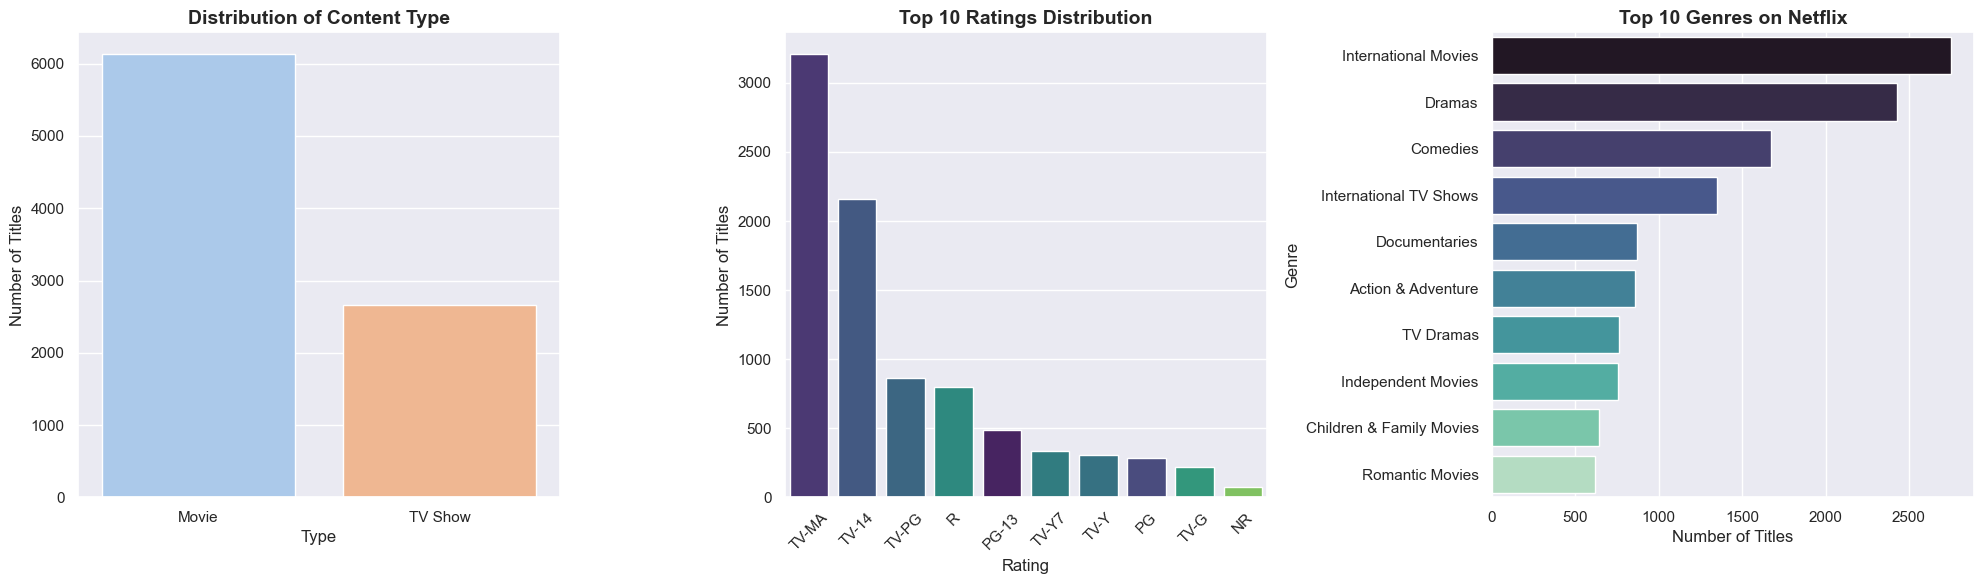

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# 1. Load the checkpoint dataset from Task 1
df = pd.read_csv('netflix_m2_checkpoint.csv')

# --- PRINT EXACT NUMBERS ---
print("--- 1. CONTENT TYPE DISTRIBUTION ---")
print(df['type'].value_counts().to_string())
print("\n--- 2. TOP 10 RATINGS DISTRIBUTION ---")
print(df['rating'].value_counts().head(10).to_string())

genres = df['listed_in'].dropna().str.split(', ').explode()
print("\n--- 3. TOP 10 GENRES DISTRIBUTION ---")
print(genres.value_counts().head(10).to_string())
print("-" * 40)

# --- CREATE VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. Content Type (Updated to fix FutureWarning)
sns.countplot(x='type', hue='type', data=df, ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Distribution of Content Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Titles')
axes[0].set_xlabel('Type')

# B. Ratings (Updated to fix FutureWarning)
top_ratings = df['rating'].value_counts().index[:10]
sns.countplot(x='rating', hue='rating', data=df, ax=axes[1], order=top_ratings, palette='viridis', legend=False)
axes[1].set_title('Top 10 Ratings Distribution', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Number of Titles')
axes[1].set_xlabel('Rating')

# C. Genres (Updated to fix FutureWarning)
top_genres = genres.value_counts().head(10)
sns.barplot(y=top_genres.index, x=top_genres.values, hue=top_genres.index, ax=axes[2], palette='mako', legend=False)
axes[2].set_title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Titles')
axes[2].set_ylabel('Genre')

plt.tight_layout()
plt.show()

--- TOP 10 COUNTRY CONTRIBUTIONS ---
country
United States     3680
India             1046
Unavailable        829
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
------------------------------------


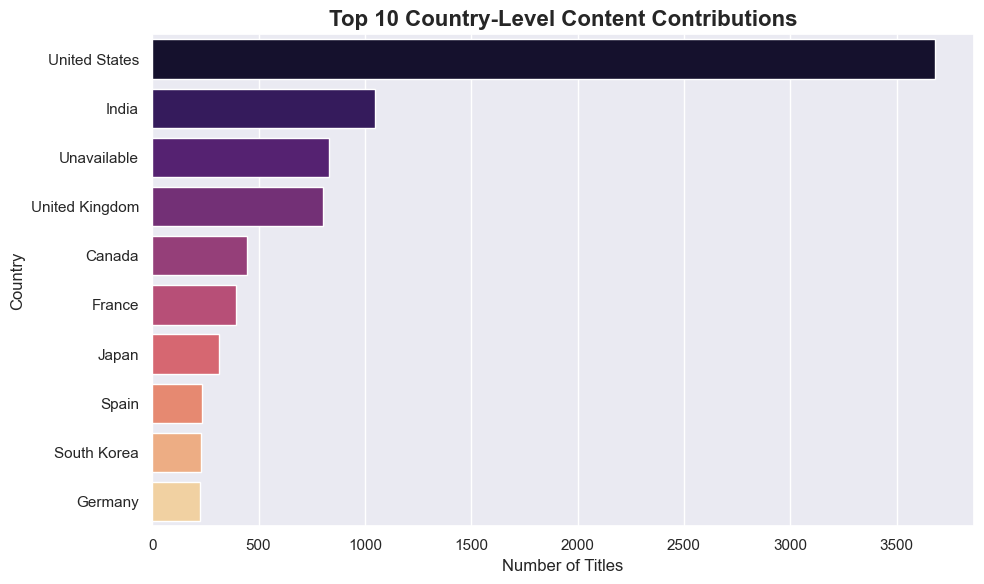

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# 1. Load the checkpoint dataset
df = pd.read_csv('netflix_m2_checkpoint.csv')

# 2. Split and explode the 'country' column to handle co-productions
# We also filter out the 'Unknown' values we filled in during Milestone 1
countries = df[df['country'] != 'Unknown']['country'].dropna().str.split(', ').explode()

# Get the top 10 contributing countries
top_countries = countries.value_counts().head(10)

# --- PRINT EXACT NUMBERS ---
print("--- TOP 10 COUNTRY CONTRIBUTIONS ---")
print(top_countries.to_string())
print("-" * 36)

# --- CREATE VISUALIZATION ---
plt.figure(figsize=(10, 6))

# Plot the data (using hue and legend=False to avoid FutureWarnings)
sns.barplot(
    y=top_countries.index, 
    x=top_countries.values, 
    hue=top_countries.index, 
    palette='magma', 
    legend=False
)

# Add titles and labels
plt.title('Top 10 Country-Level Content Contributions', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()

# Display the plot
plt.show()

In [19]:
import pandas as pd

# 1. Load the checkpoint dataset
df = pd.read_csv('netflix_m2_checkpoint.csv')

# --- Feature 1: Content Length Category ---
def categorize_length(row):
    duration = str(row['duration'])
    if row['type'] == 'Movie':
        # Extract the number of minutes
        minutes = int(duration.split(' ')[0]) if 'min' in duration else 0
        if minutes < 90:
            return 'Short Movie (<90 min)'
        elif minutes <= 120:
            return 'Medium Movie (90-120 min)'
        else:
            return 'Long Movie (>120 min)'
    else: # TV Show
        # Extract the number of seasons
        seasons = int(duration.split(' ')[0]) if 'Season' in duration else 0
        if seasons == 1:
            return 'Single Season TV Show'
        else:
            return 'Multi-Season TV Show'

# Apply the function to create the new column
df['Content Length Category'] = df.apply(categorize_length, axis=1)


# --- Feature 2: Original vs. Licensed ---
def categorize_original(row):
    # If we are missing either year, we can't compare
    if pd.isna(row['year_added']) or pd.isna(row['release_year']):
        return 'Unknown'
        
    # Proxy logic: Released within 1 year of being added to Netflix
    if row['release_year'] >= row['year_added'] - 1:
        return 'Likely Original'
    else:
        return 'Likely Licensed'

# Apply the function to create the new column
df['Original vs. Licensed'] = df.apply(categorize_original, axis=1)


# --- PRINT A PREVIEW ---
print("--- NEW DERIVED FEATURES PREVIEW ---")
# Show a few specific columns so we can verify the logic worked
preview_cols = ['title', 'type', 'duration', 'Content Length Category', 'release_year', 'year_added', 'Original vs. Licensed']
print(df[preview_cols].head(10).to_string())
print("-" * 60)

# --- SAVE THE FINAL MILESTONE 2 DATASET ---
df.to_csv('netflix_milestone2_complete.csv', index=False)
print("SUCCESS: Task 4 is complete!")
print("The final Milestone 2 dataset has been saved as 'netflix_milestone2_complete.csv'.")

--- NEW DERIVED FEATURES PREVIEW ---
                              title     type   duration    Content Length Category  release_year  year_added Original vs. Licensed
0              Dick Johnson Is Dead    Movie     90 min  Medium Movie (90-120 min)          2020        2021       Likely Original
1                     Blood & Water  TV Show  2 Seasons       Multi-Season TV Show          2021        2021       Likely Original
2                         Ganglands  TV Show   1 Season      Single Season TV Show          2021        2021       Likely Original
3             Jailbirds New Orleans  TV Show   1 Season      Single Season TV Show          2021        2021       Likely Original
4                      Kota Factory  TV Show  2 Seasons       Multi-Season TV Show          2021        2021       Likely Original
5                     Midnight Mass  TV Show   1 Season      Single Season TV Show          2021        2021       Likely Original
6  My Little Pony: A New Generation    Movie  

--- TOP 10 COUNTRY CONTRIBUTIONS ---
country
United States     3680
India             1046
Unavailable        829
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
------------------------------------


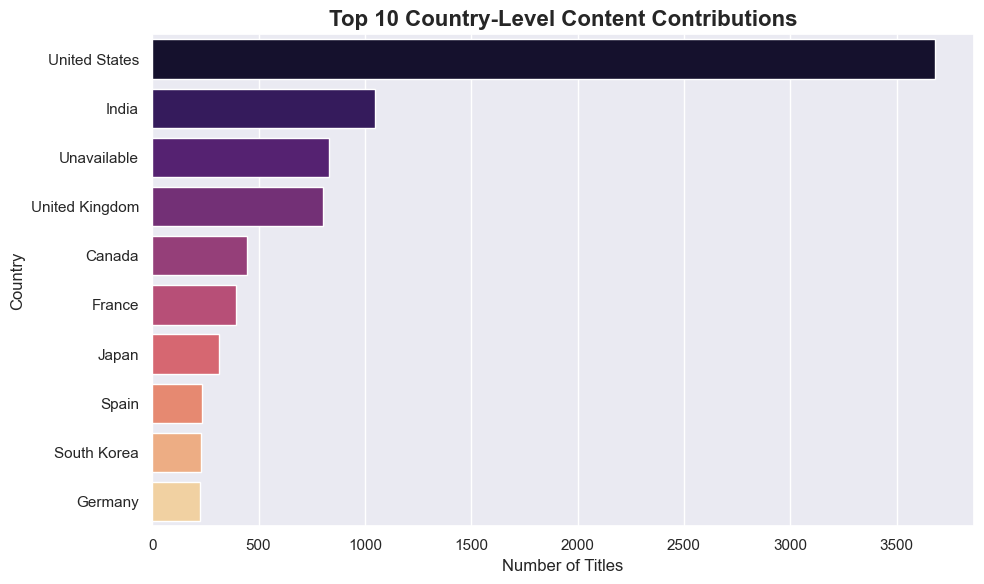

Creating derived features...

--- DERIVED FEATURES PREVIEW ---
                   title    Content Length Category Original vs. Licensed
0   Dick Johnson Is Dead  Medium Movie (90-120 min)       Likely Original
1          Blood & Water       Multi-Season TV Show       Likely Original
2              Ganglands      Single Season TV Show       Likely Original
3  Jailbirds New Orleans      Single Season TV Show       Likely Original
4           Kota Factory       Multi-Season TV Show       Likely Original

SUCCESS: Today's tasks are complete!
The data with derived features is saved as 'netflix_milestone2_complete.csv'.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# 1. Load the checkpoint dataset from our previous step
df = pd.read_csv('netflix_m2_checkpoint.csv')

# ==========================================
# Task: Identify country-level content contributions
# ==========================================
print("--- TOP 10 COUNTRY CONTRIBUTIONS ---")
# Split comma-separated countries to account for co-productions
countries = df[df['country'] != 'Unknown']['country'].dropna().str.split(', ').explode()
top_countries = countries.value_counts().head(10)
print(top_countries.to_string())
print("-" * 36)

# Generate the visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_countries.index, 
    x=top_countries.values, 
    hue=top_countries.index, 
    palette='magma', 
    legend=False
)
plt.title('Top 10 Country-Level Content Contributions', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# Task: Create Derived Features
# ==========================================
print("Creating derived features...")

# Feature 1: Content Length Category
def categorize_length(row):
    duration = str(row['duration'])
    if row['type'] == 'Movie':
        minutes = int(duration.split(' ')[0]) if 'min' in duration else 0
        if minutes < 90:
            return 'Short Movie (<90 min)'
        elif minutes <= 120:
            return 'Medium Movie (90-120 min)'
        else:
            return 'Long Movie (>120 min)'
    else: 
        seasons = int(duration.split(' ')[0]) if 'Season' in duration else 0
        if seasons == 1:
            return 'Single Season TV Show'
        else:
            return 'Multi-Season TV Show'

df['Content Length Category'] = df.apply(categorize_length, axis=1)

# Feature 2: Original vs. Licensed
def categorize_original(row):
    if pd.isna(row['year_added']) or pd.isna(row['release_year']):
        return 'Unknown'
    # Proxy: If added within 1 year of release, it's likely an Original
    if row['release_year'] >= row['year_added'] - 1:
        return 'Likely Original'
    else:
        return 'Likely Licensed'

df['Original vs. Licensed'] = df.apply(categorize_original, axis=1)

print("\n--- DERIVED FEATURES PREVIEW ---")
print(df[['title', 'Content Length Category', 'Original vs. Licensed']].head())

# ==========================================
# Save the Final Milestone 2 Dataset
# ==========================================
df.to_csv('netflix_milestone2_complete.csv', index=False)
print("\nSUCCESS: Today's tasks are complete!")
print("The data with derived features is saved as 'netflix_milestone2_complete.csv'.")

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd


cluster_data = df[['duration_value', 'rating']].dropna()


cluster_data_encoded = pd.get_dummies(cluster_data, columns=['rating'])


scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data_encoded)


kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

print("Clustering Complete! Here is how many titles are in each cluster:")
print(df['cluster'].value_counts())

In [23]:

if 'duration_value' not in df.columns:
    # Split '90 min' or '1 Season' into [90, 'min']
    temp_split = df['duration'].str.split(' ', expand=True)
    df['duration_value'] = pd.to_numeric(temp_split[0])
    df['duration_unit'] = temp_split[1]


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Selecting the features
X = df[['duration_value', 'release_year']].dropna()
y = df['type'].loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

print("Model Trained Successfully!")
print(f"Accuracy: {classifier.score(X_test, y_test)*100:.2f}%")

Model Trained Successfully!
Accuracy: 99.83%
